In [34]:
import polars as pl
import numpy as np
import os
import pandas as pd

In [35]:
def partition_device(ip: str, train_ratio: float = 0.7, data_frac: float = 1):
    safe_ip = ip.replace(":", "_").replace(".", "_")
    path = f"C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\per_device\\device_{safe_ip}.parquet"
    
    lf_full = pl.scan_parquet(path)

    # total rows
    total = lf_full.select(pl.len()).collect().item()
    
    # take only first X% of data (sequential)
    subset_size = int(total * data_frac)
    lf = lf_full.limit(subset_size)

    # now split this subset
    cutoff = int(subset_size * train_ratio)
    
    train_df = (
        lf.with_row_index("_idx")
        .filter(pl.col("_idx") < cutoff)
        .filter(pl.col("detailed-label") == "-")   # benign only
        .drop("_idx")
        .collect()
    )
    
    test_df = (
        lf.with_row_index("_idx")
        .filter(pl.col("_idx") >= cutoff)
        .drop("_idx")
        .collect()
    )
    
    print(f"{ip} — Using {data_frac*100:.1f}% of data ({subset_size:,} rows)")
    print(f"{ip} — Train (benign): {len(train_df):,} rows")
    print(f"{ip} — Test (mixed):   {len(test_df):,} rows")
    
    return train_df, test_df

In [3]:
def df_size_info(df, name="DF"):
    rows = df.height
    cols = df.width
    size_bytes = df.estimated_size()
    size_mb = size_bytes / (1024 ** 2)

    print(f"{name}:")
    print(f"  Rows: {rows:,}")
    print(f"  Columns: {cols}")
    print(f"  Estimated size: {size_mb:.2f} MB\n")

In [4]:
def print_label_distribution(df, col="detailed-label", name="DF"):
    vc = df[col].value_counts().sort("count", descending=True)
    
    total = df.height
    vc = vc.with_columns(
        (pl.col("count") / total * 100).alias("percentage")
    )
    
    print(f"{name} Label Distribution:")
    print(vc)
    print()

In [76]:
train_df,test_df = partition_device("192_168_1_196") 
df_size_info(train_df)
df_size_info(test_df) 
print_label_distribution(train_df)
print_label_distribution(test_df)

192_168_1_196 — Using 100.0% of data (10,446,132 rows)
192_168_1_196 — Train (benign): 6,403,650 rows
192_168_1_196 — Test (mixed):   3,133,840 rows
DF:
  Rows: 6,403,650
  Columns: 14
  Estimated size: 403.06 MB

DF:
  Rows: 3,133,840
  Columns: 14
  Estimated size: 197.25 MB

DF Label Distribution:
shape: (1, 3)
┌────────────────┬─────────┬────────────┐
│ detailed-label ┆ count   ┆ percentage │
│ ---            ┆ ---     ┆ ---        │
│ cat            ┆ u32     ┆ f64        │
╞════════════════╪═════════╪════════════╡
│ -              ┆ 6403650 ┆ 100.0      │
└────────────────┴─────────┴────────────┘

DF Label Distribution:
shape: (2, 3)
┌────────────────┬─────────┬────────────┐
│ detailed-label ┆ count   ┆ percentage │
│ ---            ┆ ---     ┆ ---        │
│ cat            ┆ u32     ┆ f64        │
╞════════════════╪═════════╪════════════╡
│ -              ┆ 1857084 ┆ 59.259056  │
│ DDoS           ┆ 1276756 ┆ 40.740944  │
└────────────────┴─────────┴────────────┘



In [77]:
train_path = "C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\traintestdata\\train_192_168_1_196.parquet"
test_path  = "C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\traintestdata\\test_192_168_1_196.parquet"

train_df.write_parquet(train_path)
test_df.write_parquet(test_path)

print(f"Train saved → {train_path}")
print(f"Test  saved → {test_path}")

Train saved → C:\Users\babai\OneDrive\Desktop\CaseStudiesDatasets\traintestdata\train_192_168_1_196.parquet
Test  saved → C:\Users\babai\OneDrive\Desktop\CaseStudiesDatasets\traintestdata\test_192_168_1_196.parquet


In [78]:
path = f"C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\per_device\\device_192_168_1_196.parquet"
ts_min = (
    pl.scan_parquet(path)
    .select(pl.col("ts").min())
    .collect()
    .item()
)
print(ts_min)

1545402842.863612


In [79]:
CONN_STATES = ["SF", "S0", "S1", "S3", "SH", "SHR", "REJ", "RSTR", "OTH"]
PROTOS      = ["tcp", "udp", "icmp"]
HISTORY_FLAGS = list("ShADadttfFrRwcT^")

def engineer_features(df: pl.DataFrame, ts_min: float) -> np.ndarray:
    """
    Returns a numpy array of shape (n_rows, n_features).
    All features are numerical and scaled.
    """
    result = {}
    
    # ── Temporal ──────────────────────────────────────────────────
    # ts_relative = df["ts"] - ts_min
    # result["ts_relative"] = np.log1p(ts_relative.to_numpy( ))
    
    # ── Log-transformed numerics (handle 0s and nulls) ───────────
    cols = ["duration", "orig_bytes", "resp_bytes", "orig_pkts", "resp_pkts"]
    cols = ["orig_bytes", "resp_bytes", "orig_pkts", "resp_pkts"]
    for col in cols:
        vals = df[col].fill_null(0).fill_nan(0).to_numpy()
        result[f"{col}_log1p"] = np.log1p(vals)
    
    # ── Ratio features ────────────────────────────────────────────
    # orig = df["orig_bytes"].fill_null(0).fill_nan(0).to_numpy()
    # resp = df["resp_bytes"].fill_null(0).fill_nan(0).to_numpy()
    # result["bytes_ratio"] = resp / (orig + 1)
    
    # pkts_o = df["orig_pkts"].fill_null(0).fill_nan(0).to_numpy()
    # pkts_r = df["resp_pkts"].fill_null(0).fill_nan(0).to_numpy()
    # result["pkts_ratio"] = pkts_r / (pkts_o + 1)
    
    # ── Exact zero flags ─────────────────────────────────────────
    # dur = df["duration"].fill_null(0).fill_nan(0).to_numpy()
    # result["is_exact_zero_duration"] = (dur == 0.0).astype(np.float32)
    # result["is_zero_bytes"]          = ((orig == 0) & (resp == 0)).astype(np.float32)
    
    # ── Port features ─────────────────────────────────────────────
    # resp_p = df["id.resp_p"].to_numpy()
    # result["resp_p_well_known"]  = (resp_p <= 1023).astype(np.float32)
    # result["resp_p_registered"]  = ((resp_p > 1023) & (resp_p <= 49151)).astype(np.float32)
    # result["resp_p_ephemeral"]   = (resp_p > 49151).astype(np.float32)
    # # Specific attack-relevant ports
    # for port, name in [(6667, "irc"), (37215, "okiru"), (57722, "heartbeat"), (80, "http"), (443, "https"), (53, "dns"), (123, "ntp")]:
    #     result[f"resp_p_{name}"] = (resp_p == port).astype(np.float32)
    
    # ── conn_state one-hot ────────────────────────────────────────
    # conn = df["conn_state"].cast(pl.Utf8).to_numpy()
    # for state in CONN_STATES:
    #     result[f"conn_{state}"] = (conn == state).astype(np.float32)
    
    # ── proto one-hot ─────────────────────────────────────────────
    proto = df["proto"].cast(pl.Utf8).to_numpy()
    for p in PROTOS:
        result[f"proto_{p}"] = (proto == p).astype(np.float32)
    
    # ── history features ──────────────────────────────────────────
    # history = df["history"].fill_null("").to_numpy()
    # result["history_len"] = np.array([len(h) for h in history], dtype=np.float32)
    # for flag in HISTORY_FLAGS:
    #     result[f"hist_{flag}"] = np.array([flag in h for h in history], dtype=np.float32)
    
    # Stack into matrix
    feature_names = list(result.keys())
    feature_matrix = np.column_stack(list(result.values())).astype(np.float32)
    return feature_names, feature_matrix

In [80]:
train_f_names, train_f_matrix = engineer_features(train_df,ts_min)
feature_train_df = pd.DataFrame(train_f_matrix, columns=train_f_names)
print(feature_train_df.head().T)

                         0         1         2         3         4
orig_bytes_log1p  4.369448  3.891820  4.369448  3.891820  3.891820
resp_bytes_log1p  0.000000  3.891820  0.000000  3.891820  3.891820
orig_pkts_log1p   1.098612  0.693147  1.098612  0.693147  0.693147
resp_pkts_log1p   0.000000  0.693147  0.000000  0.693147  0.693147
proto_tcp         0.000000  0.000000  0.000000  0.000000  0.000000
proto_udp         1.000000  1.000000  1.000000  1.000000  1.000000
proto_icmp        0.000000  0.000000  0.000000  0.000000  0.000000


In [42]:
# print("Min ts_relative:", feature_train_df["ts_relative"].min())
# print("Max ts_relative:", feature_train_df["ts_relative"].max())

In [81]:
test_f_names, test_f_matrix = engineer_features(test_df,ts_min)
feature_test_df = pd.DataFrame(test_f_matrix, columns=test_f_names)
print(feature_test_df.head().T)
# print("Min ts_relative:", feature_test_df["ts_relative"].min())
# print("Max ts_relative:", feature_test_df["ts_relative"].max())

                         0         1         2         3         4
orig_bytes_log1p  0.000000  0.000000  0.000000  0.000000  0.000000
resp_bytes_log1p  0.000000  0.000000  0.000000  0.000000  0.000000
orig_pkts_log1p   0.693147  0.693147  0.693147  0.693147  0.693147
resp_pkts_log1p   0.000000  0.000000  0.000000  0.000000  0.000000
proto_tcp         1.000000  1.000000  1.000000  1.000000  1.000000
proto_udp         0.000000  0.000000  0.000000  0.000000  0.000000
proto_icmp        0.000000  0.000000  0.000000  0.000000  0.000000


In [82]:
print("Original train_df rows:", len(train_df))
print("Original test_df rows:", len(test_df))
print("New train_df rows:", len(train_f_matrix))
print("New test_df rows:", len(test_f_matrix))

Original train_df rows: 6403650
Original test_df rows: 3133840
New train_df rows: 6403650
New test_df rows: 3133840


In [83]:
def create_sequences(features: np.ndarray, window_size: int = 50, step: int = 25) -> np.ndarray:
    """
    Sliding window over the feature matrix.
    window_size: how many consecutive connections per sequence
    step: how many rows to advance between windows (overlap = window_size - step)
    Returns shape: (n_sequences, window_size, n_features)
    """
    sequences = []
    for i in range(0, len(features) - window_size, step):
        sequences.append(features[i : i + window_size])
    return np.array(sequences, dtype=np.float32)

In [84]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler_path = "C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\artifacts\\scaler_192_168_1_196.pkl"

# Fit ONLY on benign training sequences
scaler = StandardScaler()

# train_features = engineer_features(train_df, ts_min=train_df["ts"].min())
train_seq = create_sequences(train_f_matrix, window_size=50, step=25)

# Reshape for scaler: (n_seq * window_size, n_features)
n_seq, win, n_feat = train_seq.shape
train_flat = train_seq.reshape(-1, n_feat)
scaler.fit(train_flat)
train_seq_scaled = scaler.transform(train_flat).reshape(n_seq, win, n_feat)

# Apply same scaler to test (don't refit)
# test_features = engineer_features(test_df, ts_min=train_df["ts"].min())  # use train ts_min
test_seq = create_sequences(test_f_matrix, window_size=50, step=25)
n_seq_t, win, n_feat = test_seq.shape
test_seq_scaled = scaler.transform(test_seq.reshape(-1, n_feat)).reshape(n_seq_t, win, n_feat)

joblib.dump(scaler, scaler_path)

['C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\artifacts\\scaler_192_168_1_196.pkl']

In [85]:
def seq_to_parquet(seq_array, file_path):
    """
    seq_array: numpy array of shape (n_seq, window_size, n_features)
    Flattens each sequence into a single row: window_size * n_features columns
    """
    n_seq, win, n_feat = seq_array.shape
    # flatten each sequence
    flat_seq = seq_array.reshape(n_seq, win * n_feat)
    
    # generate column names: feat0_t0, feat1_t0, ..., featN_tW
    columns = []
    for t in range(win):
        for f in range(n_feat):
            columns.append(f"f{f}_t{t}")
    
    df = pd.DataFrame(flat_seq, columns=columns)
    df.to_parquet(file_path, index=False)
    print(f"Saved {file_path} ({df.shape[0]} rows, {df.shape[1]} columns)")

# ── Save train ──
seq_to_parquet(train_seq_scaled, "C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\staging\\train_sequences_192_168_1_196.parquet")

# ── Save test ──
seq_to_parquet(test_seq_scaled, "C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\staging\\test_sequences_192_168_1_196.parquet")

Saved C:\Users\babai\OneDrive\Desktop\CaseStudiesDatasets\staging\train_sequences_192_168_1_196.parquet (256144 rows, 350 columns)
Saved C:\Users\babai\OneDrive\Desktop\CaseStudiesDatasets\staging\test_sequences_192_168_1_196.parquet (125352 rows, 350 columns)


In [48]:
import torch
import torch.nn as nn
import numpy as np

class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, latent_size, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=0.2)
        self.fc_mu     = nn.Linear(hidden_size, latent_size)
        self.fc_logvar = nn.Linear(hidden_size, latent_size)
    
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)       # h_n: (num_layers, batch, hidden)
        h = h_n[-1]                       # take last layer's hidden state
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar


class LSTMDecoder(nn.Module):
    def __init__(self, latent_size, hidden_size, output_size, seq_len, num_layers=2):
        super().__init__()
        self.seq_len = seq_len
        self.fc      = nn.Linear(latent_size, hidden_size)
        self.lstm    = nn.LSTM(hidden_size, hidden_size, num_layers=num_layers,
                               batch_first=True, dropout=0.2)
        self.output  = nn.Linear(hidden_size, output_size)
    
    def forward(self, z):
        h = self.fc(z).unsqueeze(1)               # (batch, 1, hidden)
        h = h.repeat(1, self.seq_len, 1)          # (batch, seq_len, hidden)
        out, _ = self.lstm(h)
        return self.output(out)                   # (batch, seq_len, output_size)


class LSTMVAE(nn.Module):
    def __init__(self, input_size, hidden_size=128, latent_size=32, seq_len=50, num_layers=2):
        super().__init__()
        self.encoder = LSTMEncoder(input_size, hidden_size, latent_size, num_layers)
        self.decoder = LSTMDecoder(latent_size, hidden_size, input_size, seq_len, num_layers)
    
    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterise(mu, logvar)
        x_hat      = self.decoder(z)
        return x_hat, mu, logvar


def vae_loss(x, x_hat, mu, logvar, beta=1.0):
    # Reconstruction loss: how well did we rebuild the sequence?
    recon = nn.functional.mse_loss(x_hat, x, reduction="mean")
    # KL divergence: keeps latent space well-structured
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl, recon, kl

In [49]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset

def train_vae(model, train_sequences, epochs=50, batch_size=64, lr=1e-3, beta_max=1.0, kl_anneal_epochs=20,):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = model.to(device)
    
    X      = torch.tensor(train_sequences, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=True)
    # Note: shuffle=True is fine HERE because we already made sequences
    # The temporal order is captured within each sequence window

    history = {"train_loss": [], "train_recon": [], "train_kl": [],
               "mu_mean": [], "mu_std": []}
    
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        model.train()
        total_loss = recon_loss = kl_loss = 0
        beta = min(beta_max, beta_max * epoch / kl_anneal_epochs)
        
        for (batch,) in loader:
            batch = batch.to(device)
            optimiser.zero_grad()
            
            x_hat, mu, logvar = model(batch)
            loss, recon, kl   = vae_loss(batch, x_hat, mu, logvar, beta=beta)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()
            
            total_loss += loss.item()
            recon_loss += recon.item()
            kl_loss    += kl.item()
        
        n = len(loader)
        n_samples = len(loader.dataset)
        avg_loss  = total_loss / n_samples
        avg_recon = recon_loss / n_samples
        avg_kl    = kl_loss / n_samples
        
        # --- Monitor latent variables ---
        mu_mean = mu.mean().item()
        mu_std  = mu.std().item()
        
        history["train_loss"].append(avg_loss)
        history["train_recon"].append(avg_recon)
        history["train_kl"].append(avg_kl)
        history["mu_mean"].append(mu_mean)
        history["mu_std"].append(mu_std)

        print(f"Epoch {epoch+1:3d} | Loss: {total_loss/n_samples:.4f} | Recon: {recon_loss/n_samples:.4f} | KL: {kl_loss/n_samples:.4f} | β={beta:.3f}")
        print(f"          μ mean: {mu_mean:.4f}, μ std: {mu_std:.4f}")

    plt.plot(history["train_loss"], label="Total Loss")
    plt.plot(history["train_recon"], label="Reconstruction")
    plt.plot(history["train_kl"], label="KL")
    plt.legend(); plt.show()
    
    return model

In [50]:
def get_anomaly_scores(model, sequences):
    """Returns per-sequence reconstruction error."""
    model.eval()
    device = next(model.parameters()).device
    
    X      = torch.tensor(sequences, dtype=torch.float32).to(device)
    scores = []
    
    with torch.no_grad():
        for i in range(0, len(X), 256):
            batch         = X[i:i+256]
            x_hat, mu, _ = model(batch)
            # Mean squared error per sequence
            recon_err     = ((batch - x_hat) ** 2).mean(dim=[1, 2])
            scores.extend(recon_err.cpu().numpy())
    
    return np.array(scores)

In [52]:
import polars as pl 

train_df = pl.read_parquet("C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\staging\\train_sequences_192_168_1_196.parquet")
test_df  = pl.read_parquet("C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\staging\\test_sequences_192_168_1_196.parquet")

In [53]:
print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)
print("\nTrain columns:", train_df.columns)
print("\nTrain sample:")
print(train_df.head(3))

Train shape: (256144, 850)
Test shape:  (125352, 850)

Train columns: ['f0_t0', 'f1_t0', 'f2_t0', 'f3_t0', 'f4_t0', 'f5_t0', 'f6_t0', 'f7_t0', 'f8_t0', 'f9_t0', 'f10_t0', 'f11_t0', 'f12_t0', 'f13_t0', 'f14_t0', 'f15_t0', 'f16_t0', 'f0_t1', 'f1_t1', 'f2_t1', 'f3_t1', 'f4_t1', 'f5_t1', 'f6_t1', 'f7_t1', 'f8_t1', 'f9_t1', 'f10_t1', 'f11_t1', 'f12_t1', 'f13_t1', 'f14_t1', 'f15_t1', 'f16_t1', 'f0_t2', 'f1_t2', 'f2_t2', 'f3_t2', 'f4_t2', 'f5_t2', 'f6_t2', 'f7_t2', 'f8_t2', 'f9_t2', 'f10_t2', 'f11_t2', 'f12_t2', 'f13_t2', 'f14_t2', 'f15_t2', 'f16_t2', 'f0_t3', 'f1_t3', 'f2_t3', 'f3_t3', 'f4_t3', 'f5_t3', 'f6_t3', 'f7_t3', 'f8_t3', 'f9_t3', 'f10_t3', 'f11_t3', 'f12_t3', 'f13_t3', 'f14_t3', 'f15_t3', 'f16_t3', 'f0_t4', 'f1_t4', 'f2_t4', 'f3_t4', 'f4_t4', 'f5_t4', 'f6_t4', 'f7_t4', 'f8_t4', 'f9_t4', 'f10_t4', 'f11_t4', 'f12_t4', 'f13_t4', 'f14_t4', 'f15_t4', 'f16_t4', 'f0_t5', 'f1_t5', 'f2_t5', 'f3_t5', 'f4_t5', 'f5_t5', 'f6_t5', 'f7_t5', 'f8_t5', 'f9_t5', 'f10_t5', 'f11_t5', 'f12_t5', 'f13_t5',

In [55]:
import numpy as np

N_FEATURES  = 17   # f0 to f40
WINDOW_SIZE = 50   # t0 to t49
N_COLS      = N_FEATURES * WINDOW_SIZE  # should be 2050

print(f"Columns: {train_df.shape[1]} (expected {N_COLS})")

train_np = train_df.to_numpy().astype(np.float32)
test_np  = test_df.to_numpy().astype(np.float32)

train_seq = train_np.reshape(-1, WINDOW_SIZE, N_FEATURES)
test_seq  = test_np.reshape(-1, WINDOW_SIZE, N_FEATURES)

print(f"Train sequences shape: {train_seq.shape}")  # (256144, 50, 41)
print(f"Test sequences shape:  {test_seq.shape}")   # (125352, 50, 41)

# ── Sanity check — no NaNs or Infs ────────────────────────────────
print(f"Train NaN: {np.isnan(train_seq).sum()}")
print(f"Train Inf: {np.isinf(train_seq).sum()}")

Columns: 850 (expected 850)
Train sequences shape: (256144, 50, 17)
Test sequences shape:  (125352, 50, 17)
Train NaN: 0
Train Inf: 0


c:\Users\babai\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Model parameters: 55,591
Epoch   1 | Loss: 0.0113 | Recon: 0.0113 | KL: 0.0543 | β=0.000
          μ mean: 0.0917, μ std: 1.6319
Epoch   2 | Loss: 0.0113 | Recon: 0.0112 | KL: 0.0026 | β=0.050
          μ mean: -0.0036, μ std: 0.3170
Epoch   3 | Loss: 0.0112 | Recon: 0.0110 | KL: 0.0021 | β=0.100
          μ mean: -0.0235, μ std: 0.2849
Epoch   4 | Loss: 0.0109 | Recon: 0.0106 | KL: 0.0020 | β=0.150
          μ mean: 0.0111, μ std: 0.2921
Epoch   5 | Loss: 0.0105 | Recon: 0.0101 | KL: 0.0020 | β=0.200
          μ mean: -0.0050, μ std: 0.2855
Epoch   6 | Loss: 0.0104 | Recon: 0.0099 | KL: 0.0019 | β=0.250
          μ mean: 0.0185, μ std: 0.2749
Epoch   7 | Loss: 0.0102 | Recon: 0.0097 | KL: 0.0017 | β=0.300
          μ mean: 0.0096, μ std: 0.3384
Epoch   8 | Loss: 0.0101 | Recon: 0.0095 | KL: 0.0017 | β=0.350
          μ mean: -0.0082, μ std: 0.2615
Epoch   9 | Loss: 0.0101 | Recon: 0.0094 | KL: 0.0016 | β=0.400
          μ mean: 0.0069, μ std: 0.2475
Epoch  10 | Loss: 0.0098 | Recon: 0

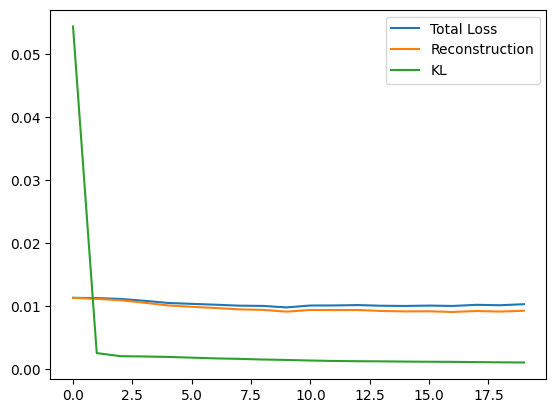

Model saved → C:\Users\babai\OneDrive\Desktop\CaseStudiesDatasets\models\model_lstm_vae_v2_192_168_1_196_lstm_vae.pt


In [86]:
N_FEATURES = 7
model = LSTMVAE(
    input_size  = N_FEATURES,   # 41
    hidden_size = 64,
    latent_size = 16,
    seq_len     = WINDOW_SIZE,  # 50
    num_layers  = 1
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

# ── Train ──────────────────────────────────────────────────────────
model = train_vae(
    model            = model,
    train_sequences  = train_seq_scaled,
    epochs           = 20,
    batch_size       = 64,
    lr               = 1e-3,
    beta_max         = 1.0,
    kl_anneal_epochs = 20
)

model_path = f"C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\models\\model_lstm_vae_v2_192_168_1_196_lstm_vae.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "config": {
        "input_size":  N_FEATURES,
        "hidden_size": 64,
        "latent_size": 16,
        "seq_len":     WINDOW_SIZE,
        "num_layers":  1,
    },
    "ts_min": ts_min,
}, model_path)
print(f"Model saved → {model_path}")

In [28]:
import polars as pl
test_raw_df  = pl.read_parquet("C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\traintestdata\\test_192_168_1_196.parquet")
train_raw_df  = pl.read_parquet("C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\traintestdata\\train_192_168_1_196.parquet")

In [29]:
print(test_raw_df.columns)
print(train_raw_df.columns)

['ts', 'id.orig_h', 'id.orig_p', 'id.resp_p', 'proto', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'history', 'orig_pkts', 'resp_pkts', 'label', 'detailed-label']
['ts', 'id.orig_h', 'id.orig_p', 'id.resp_p', 'proto', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'history', 'orig_pkts', 'resp_pkts', 'label', 'detailed-label']


In [31]:
import numpy as np
test_seq_labels = []
train_seq_labels = []
test_raw_labels = (test_raw_df["detailed-label"] != "-").to_numpy().astype(int)
train_raw_labels = (train_raw_df["detailed-label"] != "-").to_numpy().astype(int)
WINDOW_SIZE = 50
STEP_SIZE = 25

test_seq_labels = []
for start in range(0, len(test_raw_labels) - WINDOW_SIZE, STEP_SIZE):
    window_labels = test_raw_labels[start : start + WINDOW_SIZE]
    test_seq_labels.append(int(window_labels.any()))  # 1 if any malicious in window

test_seq_labels = np.array(test_seq_labels)

print(f"Test sequences — Benign: {(test_seq_labels==0).sum():,} | "
      f"Malicious: {(test_seq_labels==1).sum():,}")

train_seq_labels = []
for start in range(0, len(train_raw_labels) - WINDOW_SIZE, STEP_SIZE):
    window_labels = train_raw_labels[start : start + WINDOW_SIZE]
    train_seq_labels.append(int(window_labels.any()))  # 1 if any malicious in window

train_seq_labels = np.array(train_seq_labels)

print(f"Train sequences — Benign: {(train_seq_labels==0).sum():,} | "
      f"Malicious: {(train_seq_labels==1).sum():,}")

Test sequences — Benign: 73,366 | Malicious: 51,986
Train sequences — Benign: 256,144 | Malicious: 0


In [32]:
new_test_df  = pl.read_parquet("C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\staging\\test_sequences_192_168_1_196.parquet")
new_train_df = pl.read_parquet("C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\staging\\train_sequences_192_168_1_196.parquet")
import numpy as np

N_FEATURES  = 41   # f0 to f40
WINDOW_SIZE = 50   # t0 to t49
N_COLS      = N_FEATURES * WINDOW_SIZE  # should be 2050

print(f"Columns: {new_train_df.shape[1]} (expected {N_COLS})")

new_train_np = new_train_df.to_numpy().astype(np.float32)
new_test_np  = new_test_df.to_numpy().astype(np.float32)

new_train_seq = new_train_np.reshape(-1, WINDOW_SIZE, N_FEATURES)
new_test_seq  = new_test_np.reshape(-1, WINDOW_SIZE, N_FEATURES)

print(f"Train sequences shape: {new_train_seq.shape}")  # (256144, 50, 41)
print(f"Test sequences shape:  {new_test_seq.shape}")   # (125352, 50, 41)

# ── Sanity check — no NaNs or Infs ────────────────────────────────
print(f"Train NaN: {np.isnan(new_train_seq).sum()}")
print(f"Train Inf: {np.isinf(new_train_seq).sum()}")

Columns: 2050 (expected 2050)
Train sequences shape: (256144, 50, 41)
Test sequences shape:  (125352, 50, 41)
Train NaN: 0
Train Inf: 0


In [88]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, classification_report
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model.to(DEVICE)
model.eval()
recon_scores = []
# test_model_path = "C:\\Users\\babai\\OneDrive\\Desktop\\CaseStudiesDatasets\\models\\model_lstm_vae_v1_192_168_1_196_lstm_vae.pt"
# checkpoint = torch.load(test_model_path, map_location=DEVICE)

# config = checkpoint["config"]

# model = LSTMVAE(
#     input_size=config["input_size"],
#     hidden_size=config["hidden_size"],
#     latent_size=config["latent_size"],
#     seq_len=config["seq_len"],
#     num_layers=config["num_layers"],
# ).to(DEVICE)

# model.load_state_dict(checkpoint["model_state_dict"])
# model.eval()

test_loader  = DataLoader(test_seq_scaled,  batch_size=256, shuffle=False,
                          num_workers=0)

with torch.no_grad():
    for (batch) in test_loader:
        batch         = batch.to(DEVICE)
        x_hat, mu, _ = model(batch)
        # Per-sequence reconstruction error
        # err = ((batch - x_hat) ** 2).mean(dim=[1, 2])
        err = ((batch - x_hat) ** 2).mean(dim=2).max(dim=1).values
        recon_scores.extend(err.cpu().numpy())

recon_scores = np.array(recon_scores)

# ── ROC-AUC ────────────────────────────────────────────────────────────────
auc = roc_auc_score(test_seq_labels, recon_scores)
print(f"\nROC-AUC: {auc:.4f}")

# ── Find best threshold ────────────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, f1_score

precision, recall, thresholds = precision_recall_curve(test_seq_labels, recon_scores)
f1_scores  = 2 * precision * recall / (precision + recall + 1e-8)
best_idx   = f1_scores.argmax()
best_thresh = thresholds[best_idx]

print(f"Best threshold: {best_thresh:.4f}")
print(f"Best F1:        {f1_scores[best_idx]:.4f}")

predictions = (recon_scores > best_thresh).astype(int)
print("\nClassification Report:")
print(classification_report(test_seq_labels, predictions,
                             target_names=["Benign", "Malicious"]))


ROC-AUC: 0.9704
Best threshold: 0.5731
Best F1:        0.9274

Classification Report:
              precision    recall  f1-score   support

      Benign       0.93      0.98      0.95     73366
   Malicious       0.96      0.89      0.93     51986

    accuracy                           0.94    125352
   macro avg       0.95      0.94      0.94    125352
weighted avg       0.94      0.94      0.94    125352



In [75]:
print(train_seq_scaled[0])

[[ 6.4811111e+01 -9.6460115e-03  1.7837046e-01 -1.6775271e-02
  -4.6935680e+01  4.6935680e+01  0.0000000e+00]
 [ 5.7724842e+01  9.3698685e+01 -9.9316341e-01  4.4588806e+01
  -4.6935680e+01  4.6935680e+01  0.0000000e+00]
 [ 6.4811111e+01 -9.6460115e-03  1.7837046e-01 -1.6775271e-02
  -4.6935680e+01  4.6935680e+01  0.0000000e+00]
 [ 5.7724842e+01  9.3698685e+01 -9.9316341e-01  4.4588806e+01
  -4.6935680e+01  4.6935680e+01  0.0000000e+00]
 [ 5.7724842e+01  9.3698685e+01 -9.9316341e-01  4.4588806e+01
  -4.6935680e+01  4.6935680e+01  0.0000000e+00]
 [ 6.4811111e+01 -9.6460115e-03  1.7837046e-01 -1.6775271e-02
  -4.6935680e+01  4.6935680e+01  0.0000000e+00]
 [-1.5755178e-02 -9.6460115e-03 -9.9316341e-01 -1.6775271e-02
  -4.6935680e+01  4.6935680e+01  0.0000000e+00]
 [ 6.4811111e+01 -9.6460115e-03  1.7837046e-01 -1.6775271e-02
  -4.6935680e+01  4.6935680e+01  0.0000000e+00]
 [ 6.4811111e+01 -9.6460115e-03  1.7837046e-01 -1.6775271e-02
  -4.6935680e+01  4.6935680e+01  0.0000000e+00]
 [ 5.77248